In [14]:
import pandas as pd
import numpy as np

In [15]:
PATH = './data'
TARGET = 'SalePrice'

In [16]:
# pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.expand_frame_repr', False)

In [17]:
df = pd.read_csv(PATH + "/train.csv")
df_test = pd.read_csv(PATH + "/test.csv")

In [18]:
from sklearn.model_selection import train_test_split

# X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    df, y, test_size=.2, shuffle=True, random_state=1337
)

train_ids = X_train["Id"]
test_ids = X_test["Id"]

print(f"X_train shape {X_train.shape}")
print(f"X_test shape {X_test.shape}")

X_train shape (1168, 81)
X_test shape (292, 81)


In [19]:
print(X_train.describe())

                Id   MSSubClass  LotFrontage        LotArea  OverallQual  OverallCond    YearBuilt  YearRemodAdd   MasVnrArea   BsmtFinSF1   BsmtFinSF2    BsmtUnfSF  TotalBsmtSF     1stFlrSF     2ndFlrSF  LowQualFinSF    GrLivArea  BsmtFullBath  BsmtHalfBath     FullBath     HalfBath  BedroomAbvGr  KitchenAbvGr  TotRmsAbvGrd   Fireplaces  GarageYrBlt   GarageCars   GarageArea   WoodDeckSF  OpenPorchSF  EnclosedPorch    3SsnPorch  ScreenPorch     PoolArea       MiscVal       MoSold       YrSold      SalePrice
count  1168.000000  1168.000000   964.000000    1168.000000  1168.000000  1168.000000  1168.000000   1168.000000  1161.000000  1168.000000  1168.000000  1168.000000  1168.000000  1168.000000  1168.000000   1168.000000  1168.000000   1168.000000   1168.000000  1168.000000  1168.000000   1168.000000   1168.000000   1168.000000  1168.000000  1103.000000  1168.000000  1168.000000  1168.000000  1168.000000    1168.000000  1168.000000  1168.000000  1168.000000   1168.000000  1168.000000 

In [20]:
print(X_train.info())

<class 'pandas.core.frame.DataFrame'>
Index: 1168 entries, 1220 to 1175
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1168 non-null   int64  
 1   MSSubClass     1168 non-null   int64  
 2   MSZoning       1168 non-null   object 
 3   LotFrontage    964 non-null    float64
 4   LotArea        1168 non-null   int64  
 5   Street         1168 non-null   object 
 6   Alley          70 non-null     object 
 7   LotShape       1168 non-null   object 
 8   LandContour    1168 non-null   object 
 9   Utilities      1168 non-null   object 
 10  LotConfig      1168 non-null   object 
 11  LandSlope      1168 non-null   object 
 12  Neighborhood   1168 non-null   object 
 13  Condition1     1168 non-null   object 
 14  Condition2     1168 non-null   object 
 15  BldgType       1168 non-null   object 
 16  HouseStyle     1168 non-null   object 
 17  OverallQual    1168 non-null   int64  
 18  OverallCon

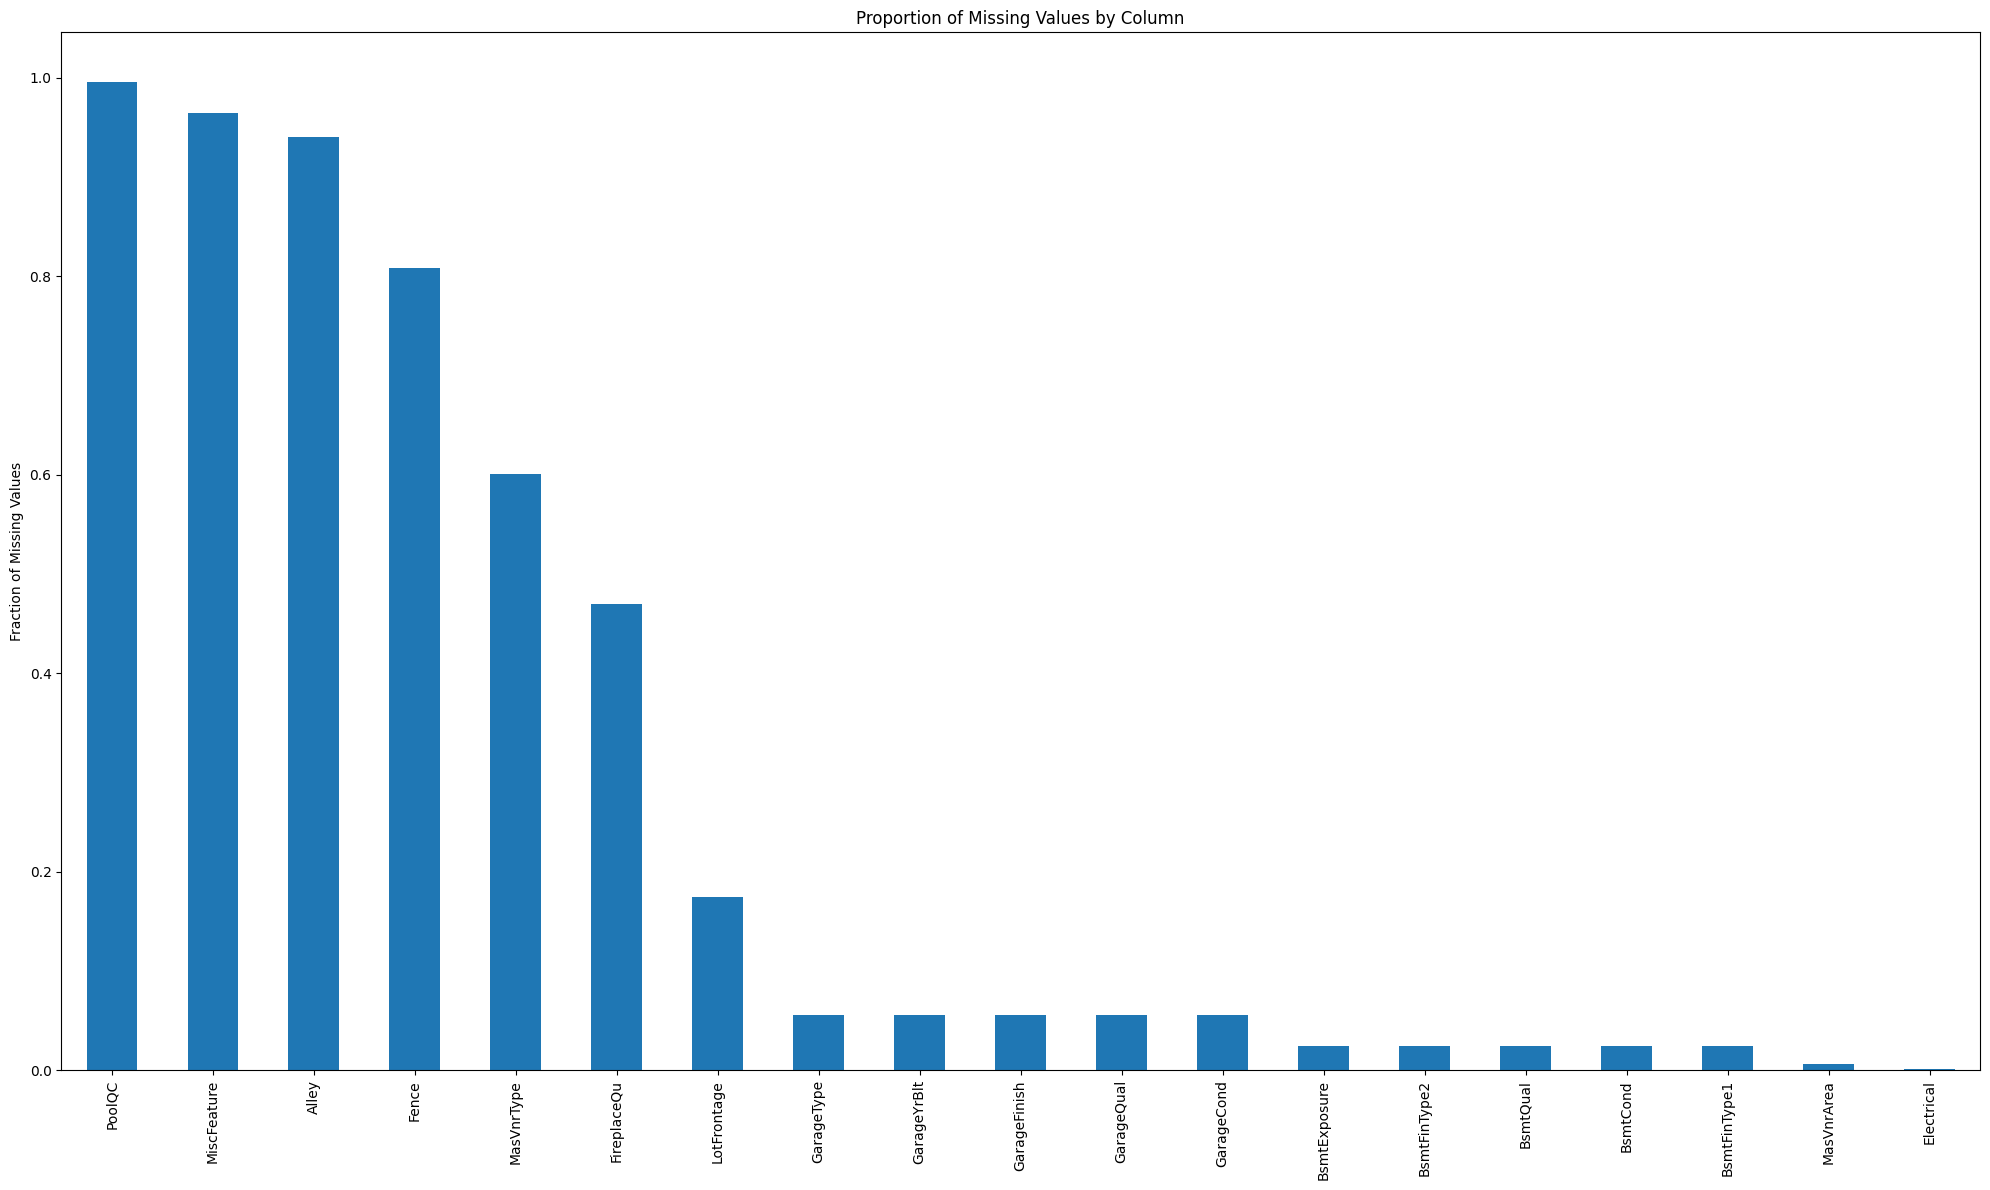

null_ratio (19):
PoolQC          0.995719
MiscFeature     0.964041
Alley           0.940068
Fence           0.808219
MasVnrType      0.601027
FireplaceQu     0.470034
LotFrontage     0.174658
GarageType      0.055651
GarageYrBlt     0.055651
GarageFinish    0.055651
GarageQual      0.055651
GarageCond      0.055651
BsmtExposure    0.024829
BsmtFinType2    0.024829
BsmtQual        0.023973
BsmtCond        0.023973
BsmtFinType1    0.023973
MasVnrArea      0.005993
Electrical      0.000856
dtype: float64


In [21]:
import matplotlib.pyplot as plt

null_ratio = X_train.isna().sum() / X_train.shape[0]
null_ratio = null_ratio[null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(20, 12))
null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.tight_layout()
plt.show()

print(f"null_ratio ({len(null_ratio)}):\n{null_ratio}")

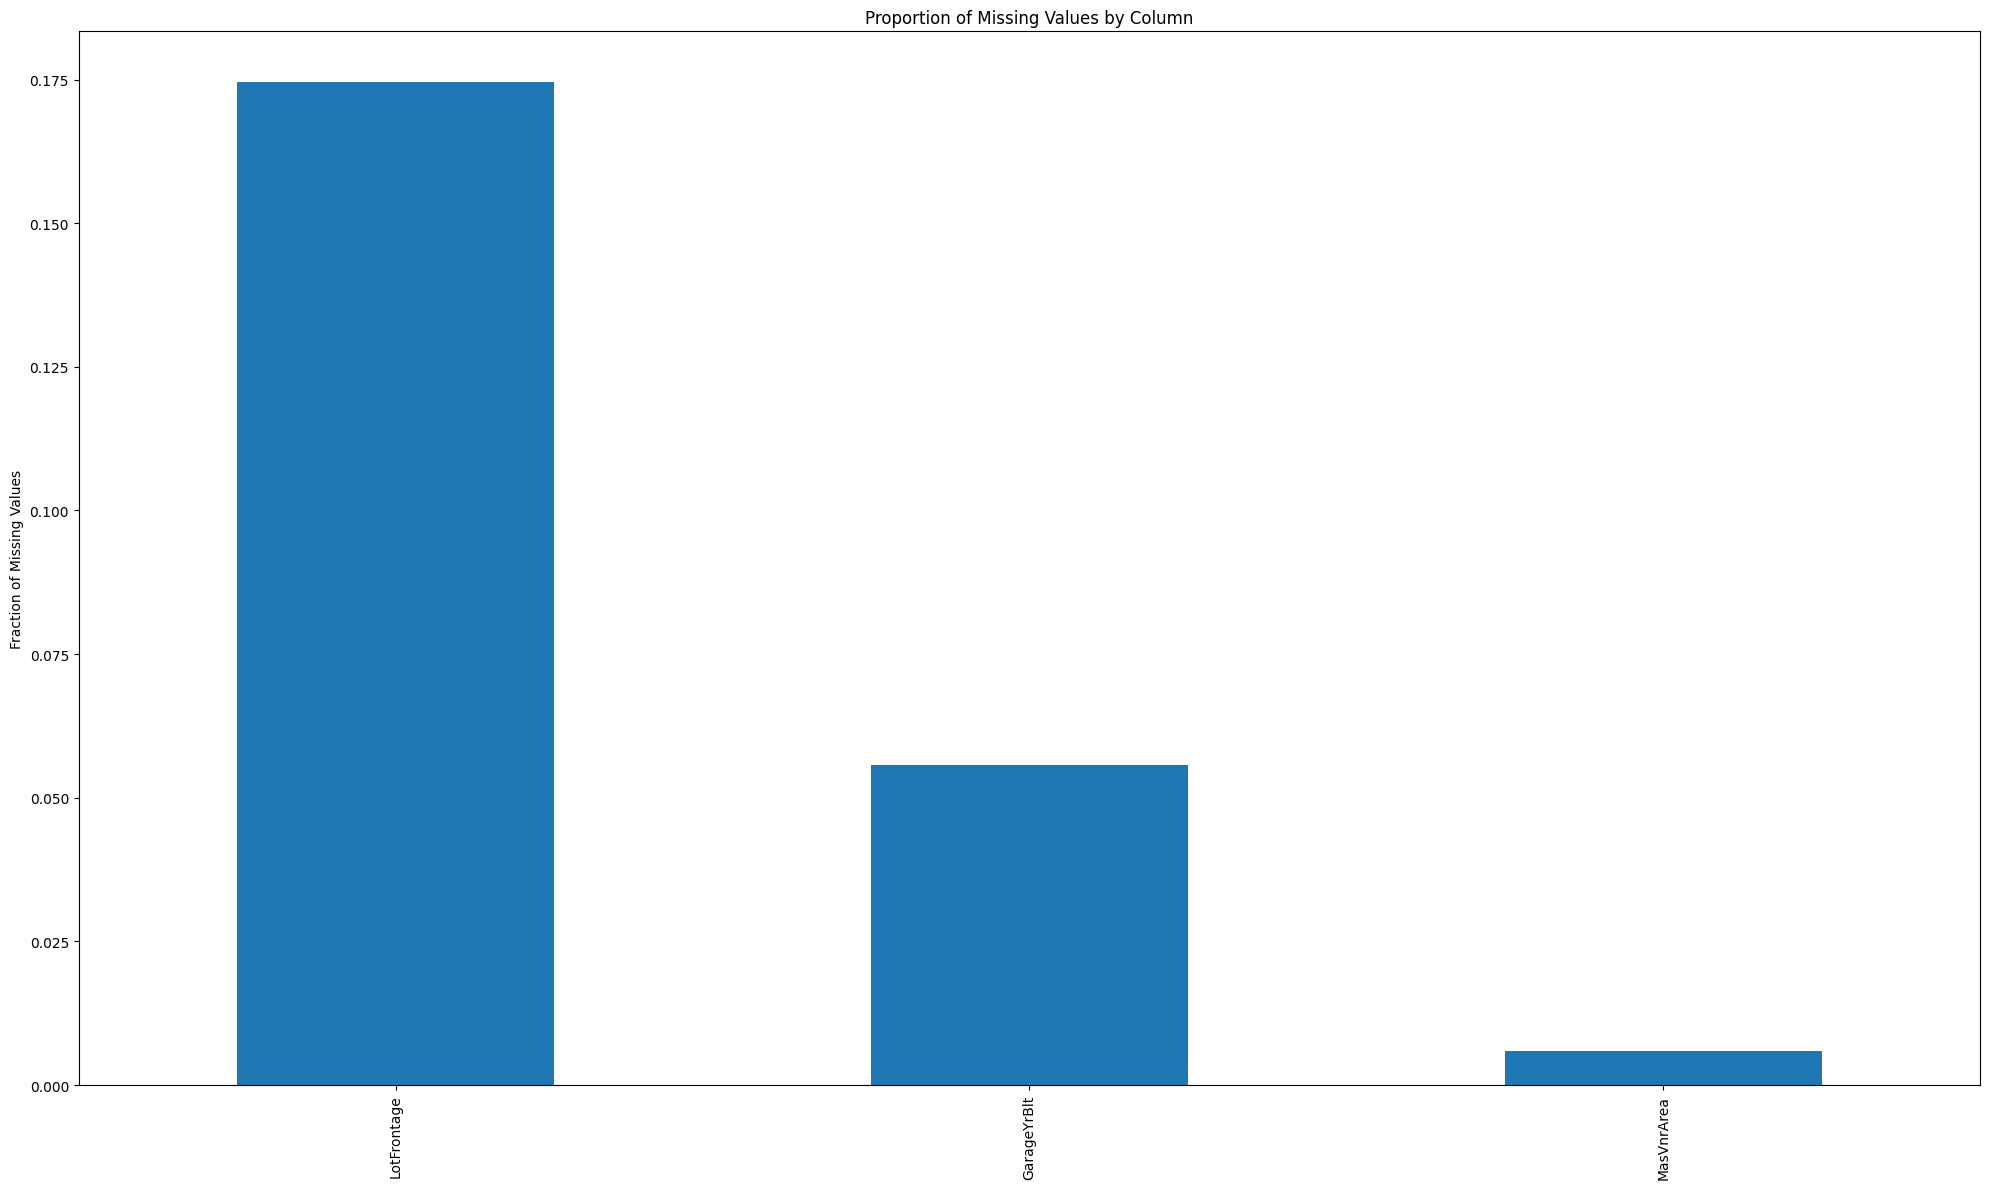

null_ratio (3):
LotFrontage    0.174658
GarageYrBlt    0.055651
MasVnrArea     0.005993
dtype: float64


In [22]:
import matplotlib.pyplot as plt

X_train_num = X_train.select_dtypes(exclude='object')
num_null_ratio = X_train_num.isna().sum() / X_train_num.shape[0]
num_null_ratio = num_null_ratio[num_null_ratio > 0].sort_values(ascending=False)

plt.figure(figsize=(20, 12))
num_null_ratio.plot(kind='bar')
plt.title('Proportion of Missing Values by Column')
plt.ylabel('Fraction of Missing Values')
plt.tight_layout()
plt.show()

print(f"null_ratio ({len(num_null_ratio)}):\n{num_null_ratio}")

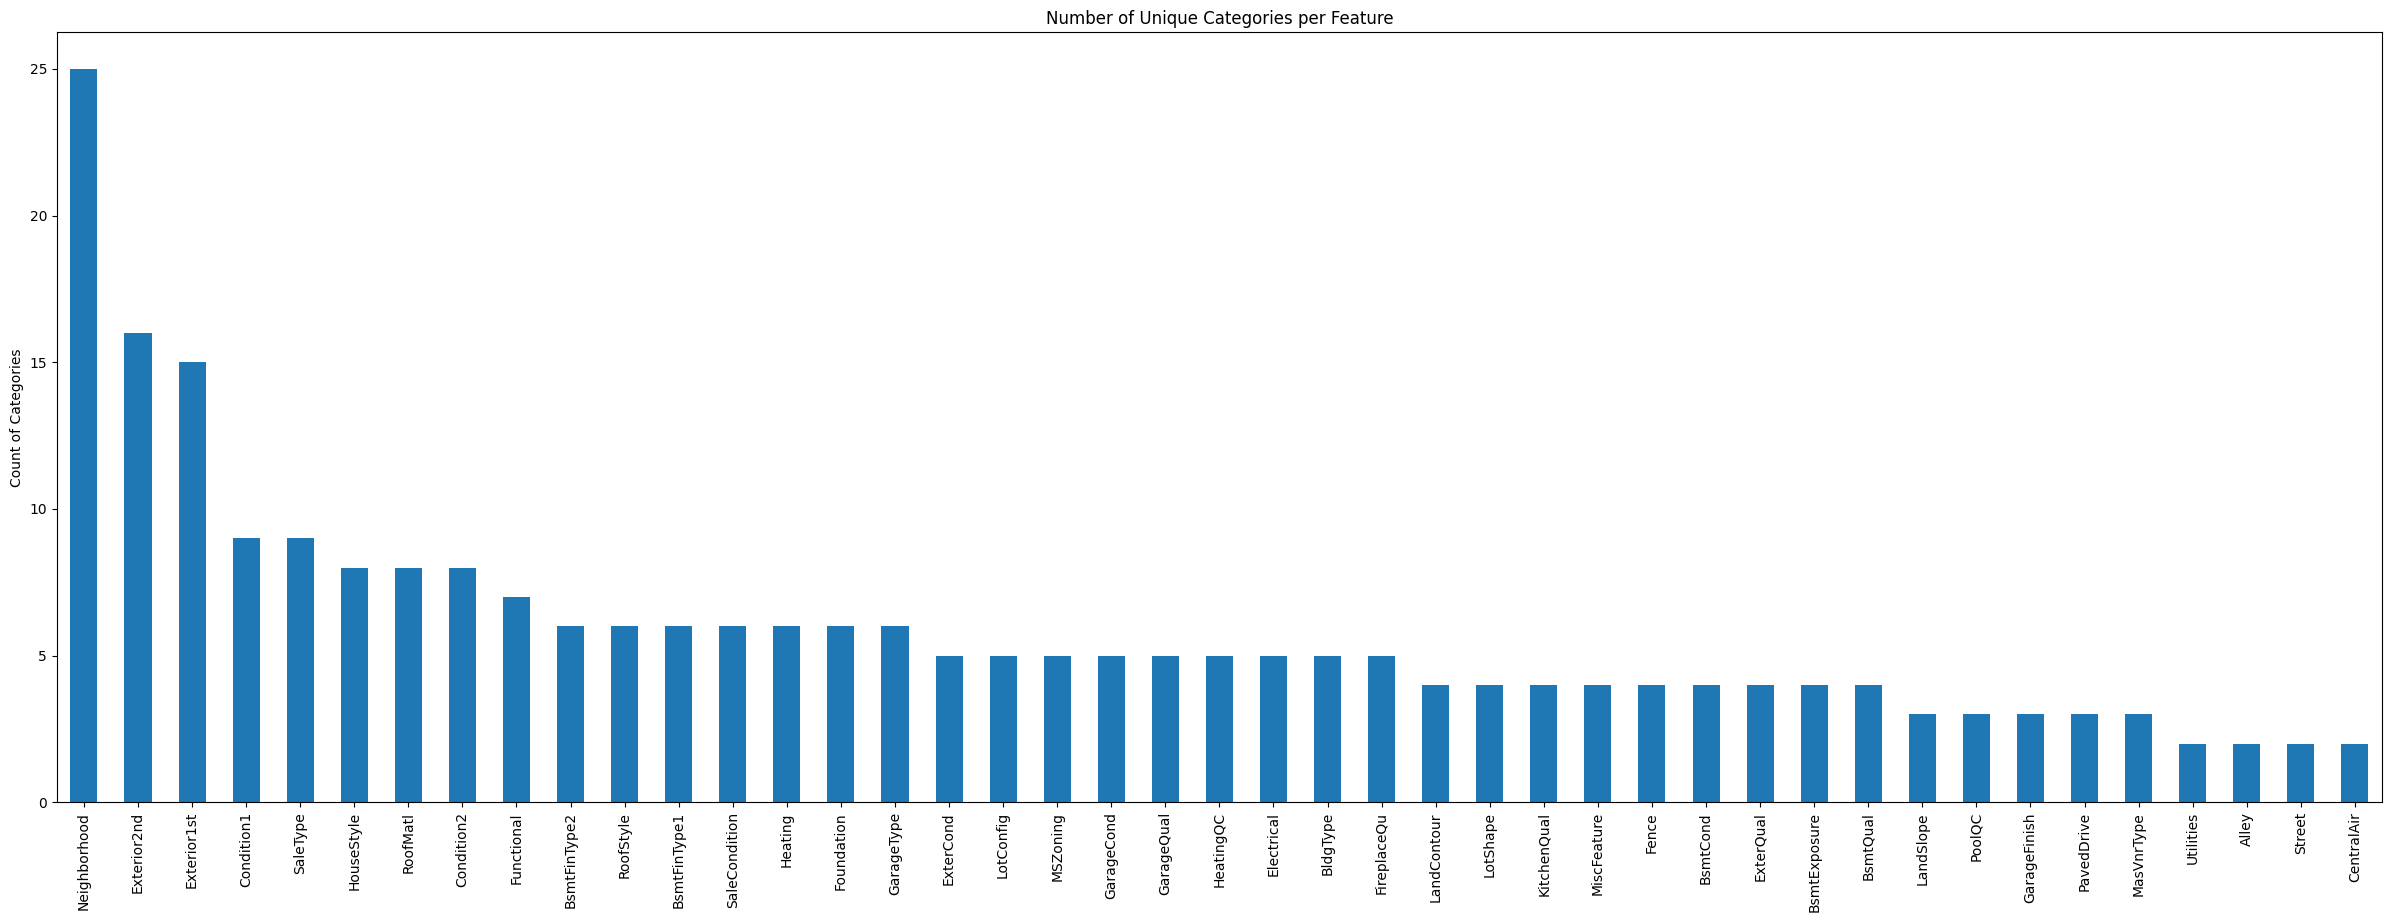

In [23]:
import matplotlib.pyplot as plt

uniques_df = df.select_dtypes(include=['object']).nunique()
uniques_df = uniques_df.sort_values(ascending=False)
uniques_df.plot(kind='bar', figsize=(30, 10))
plt.title("Number of Unique Categories per Feature")
plt.ylabel("Count of Categories")
plt.show()

In [24]:
print(X_train['PoolQC'].value_counts(dropna=False))

PoolQC
NaN    1163
Gd        2
Ex        2
Fa        1
Name: count, dtype: int64


In [25]:
print(X_train['MasVnrType'].value_counts(dropna=False))

MasVnrType
NaN        702
BrkFace    352
Stone      105
BrkCmn       9
Name: count, dtype: int64


In [26]:
print(X_train['LotFrontage'].value_counts(dropna=False))

LotFrontage
NaN      204
60.0     110
70.0      55
80.0      52
50.0      44
        ... 
137.0      1
97.0       1
33.0       1
150.0      1
160.0      1
Name: count, Length: 106, dtype: int64


In [27]:
print(X_train['GarageType'].value_counts(dropna=False))

GarageType
Attchd     691
Detchd     310
BuiltIn     74
NaN         65
Basment     15
CarPort      8
2Types       5
Name: count, dtype: int64


In [28]:
print(X_train['GarageYrBlt'].value_counts(dropna=False))

GarageYrBlt
NaN       65
2005.0    55
2006.0    50
2007.0    45
2004.0    42
          ..
1908.0     1
1924.0     1
1906.0     1
1933.0     1
1900.0     1
Name: count, Length: 98, dtype: int64


In [29]:
print(X_train['GarageFinish'].value_counts(dropna=False))

GarageFinish
Unf    485
RFn    332
Fin    286
NaN     65
Name: count, dtype: int64


In [30]:
print(X_train['MasVnrArea'].value_counts(dropna=False))

MasVnrArea
0.0      692
108.0      8
180.0      8
NaN        7
72.0       6
        ... 
66.0       1
215.0      1
388.0      1
554.0      1
337.0      1
Name: count, Length: 290, dtype: int64


In [31]:
print(X_train['Electrical'].value_counts(dropna=False))

Electrical
SBrkr    1069
FuseA      70
FuseF      24
FuseP       3
Mix         1
NaN         1
Name: count, dtype: int64


In [32]:
print(X_train['OverallCond'])

1220    5
1285    6
573     5
793     5
104     4
       ..
1191    5
1256    5
860     8
189     5
1175    5
Name: OverallCond, Length: 1168, dtype: int64


In [33]:
print(
    df.loc[df['LotShape'] == 'Reg', TARGET].mean(),
    df.loc[df['LotShape'] == 'IR1', TARGET].mean(),
    df.loc[df['LotShape'] == 'IR2', TARGET].mean(),
    df.loc[df['LotShape'] == 'IR3', TARGET].mean(),
)

164754.81837837838 206101.6652892562 239833.36585365853 216036.5


In [34]:
print(df['MSSubClass'])

0       60
1       20
2       60
3       70
4       60
        ..
1455    60
1456    20
1457    70
1458    20
1459    20
Name: MSSubClass, Length: 1460, dtype: int64


In [35]:
print(X_train['LotFrontage'].value_counts(dropna=False))

LotFrontage
NaN      204
60.0     110
70.0      55
80.0      52
50.0      44
        ... 
137.0      1
97.0       1
33.0       1
150.0      1
160.0      1
Name: count, Length: 106, dtype: int64


In [36]:
print(df['MasVnrType'].value_counts(dropna=False))
# print(df_test['ExterQual'].value_counts(dropna=False))

MasVnrType
NaN        872
BrkFace    445
Stone      128
BrkCmn      15
Name: count, dtype: int64


In [37]:
print(df['Alley'].value_counts(dropna=False))

Alley
NaN     1369
Grvl      50
Pave      41
Name: count, dtype: int64


Skewness of SalePrice: 1.88


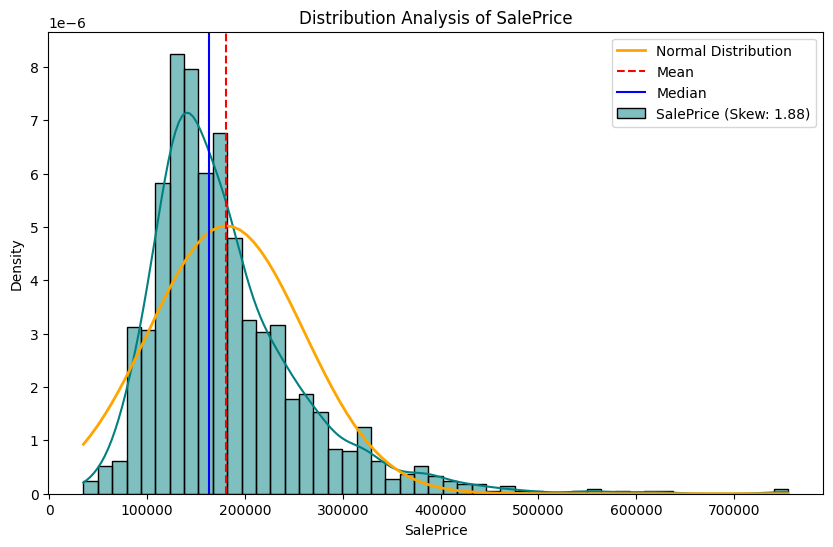

In [38]:
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import norm

# df['SalePrice'] = np.log1p(df['SalePrice'])

sp_skew = df['SalePrice'].skew()
print(f"Skewness of SalePrice: {sp_skew:.2f}")

plt.figure(figsize=(10, 6))

sns.histplot(df['SalePrice'], kde=True, color='teal', stat="density",
             label=f'SalePrice (Skew: {sp_skew:.2f})')

mu, std = norm.fit(df['SalePrice'])
x = np.linspace(df['SalePrice'].min(), df['SalePrice'].max(), 100)
p = norm.pdf(x, mu, std)
plt.plot(x, p, 'orange', linewidth=2, label='Normal Distribution')

plt.axvline(df['SalePrice'].mean(), color='red', linestyle='--', label='Mean')
plt.axvline(df['SalePrice'].median(), color='blue', linestyle='-', label='Median')

plt.title('Distribution Analysis of SalePrice')
plt.xlabel('SalePrice')
plt.ylabel('Density')
plt.legend()
plt.show()


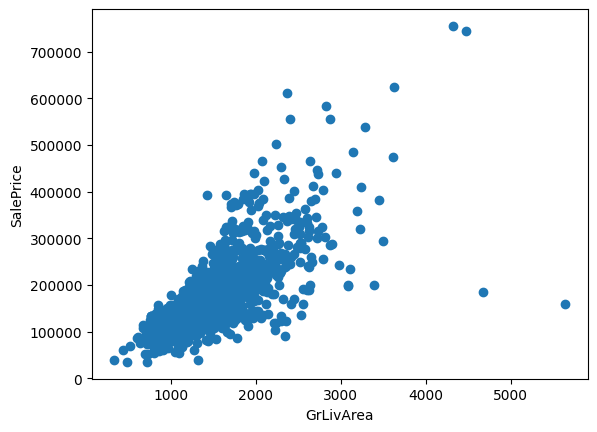

In [39]:
import matplotlib.pyplot as plt
plt.scatter(X_train['GrLivArea'], X_train['SalePrice'])
plt.xlabel('GrLivArea')
plt.ylabel('SalePrice')
plt.show()

In [40]:
outliers = X_train[(X_train['GrLivArea'] > 4000) & (X_train['SalePrice'] < 300000)]

In [41]:
# X_train.drop(outliers.index)
outliers.index

Index([523, 1298], dtype='int64')

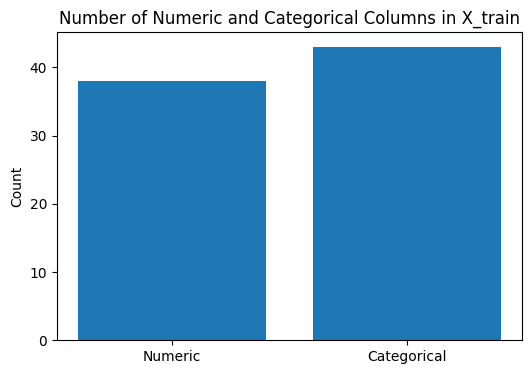

In [42]:
import matplotlib.pyplot as plt

num_count = X_train.select_dtypes(include="number").shape[1]
cat_count = X_train.select_dtypes(exclude="number").shape[1]

labels = ["Numeric", "Categorical"]
counts = [num_count, cat_count]

plt.figure(figsize=(6, 4))
plt.bar(labels, counts)
plt.title("Number of Numeric and Categorical Columns in X_train")
plt.ylabel("Count")
plt.show()

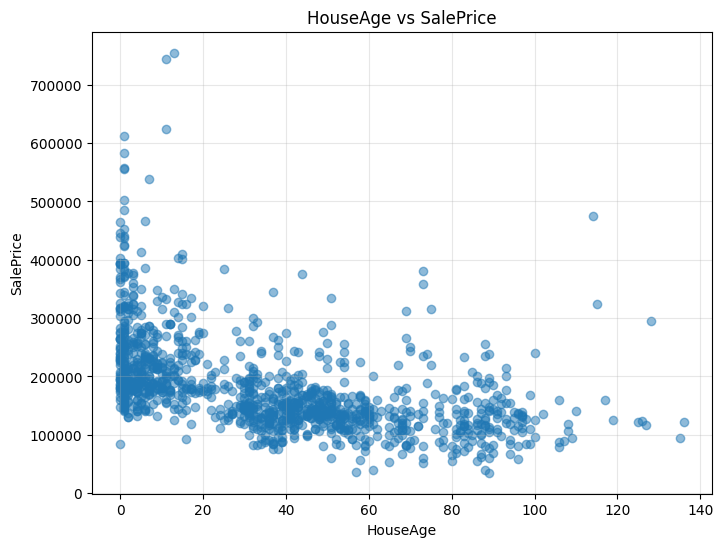

In [13]:
import matplotlib.pyplot as plt
import pandas as pd

X_copy = X_train.copy()
X_copy["SalePrice"] = y_train

X_copy = X_train.copy()
X_copy["SalePrice"] = y_train

# mask = ~((X_copy["GrLivArea"] > 3000) & (X_copy["SalePrice"] < 300000))
# X_copy = X_copy.loc[mask].copy()

if "TotalSF" not in X_copy.columns:
    X_copy["TotalSF"] = X_copy["TotalBsmtSF"] + X_copy["1stFlrSF"] + X_copy["2ndFlrSF"]

if "HouseAge" not in X_copy.columns:
    X_copy["HouseAge"] = X_copy["YrSold"] - X_copy["YearBuilt"]

# plt.figure(figsize=(8, 6))
# plt.scatter(X_copy["TotalSF"], X_copy["SalePrice"], alpha=0.5)
# plt.xlabel("TotalSF")
# plt.ylabel("SalePrice")
# plt.title("TotalSF vs SalePrice")
# plt.grid(True, alpha=0.3)
# plt.show()

plt.figure(figsize=(8, 6))
plt.scatter(X_copy["HouseAge"], X_copy["SalePrice"], alpha=0.5)
plt.xlabel("HouseAge")
plt.ylabel("SalePrice")
plt.title("HouseAge vs SalePrice")
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# X_train_t: DataFrame of features
# y_train: target (SalePrice)

df = X_train_t.copy()
df["SalePrice"] = y_train.values if hasattr(y_train, "values") else y_train

# correlations with target
corr_with_target = df.corr(numeric_only=True)["SalePrice"].drop("SalePrice")

# top N most correlated features by absolute value
top_n = 20
top_features = corr_with_target.abs().sort_values(ascending=False).head(top_n).index

# plot bar chart
plt.figure(figsize=(10, 6))
corr_with_target.loc[top_features].sort_values().plot(kind="barh")
plt.title(f"Top {top_n} Features Correlated with SalePrice")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

# heatmap for target + top features
heatmap_df = df[top_features.tolist() + ["SalePrice"]].corr(numeric_only=True)

plt.figure(figsize=(12, 10))
sns.heatmap(heatmap_df, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Top Features vs SalePrice")
plt.tight_layout()
plt.show()